# "Buy the upgrades" — does earnings-revision momentum beat the market? ✏️
### When analysts keep raising their estimates, the stock is supposed to keep winning — in plain English

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Free_lunch%3F: Busted](https://img.shields.io/badge/Free_lunch%3F-Busted-8b949e?style=flat-square)

There's a strategy as old as Wall Street research: **buy the stocks the analysts are upgrading.** When a company keeps *beating* earnings and the consensus estimate keeps getting **revised up**, the story says the stock keeps outrunning the market for months. It has a four-decade academic pedigree and it *sounds* like obvious free money.

So we put a transparent version of it on the dissecting table: rank stocks by how much they beat and how fast their estimates are rising, buy the top, short the bottom, and ask the only question that matters — **do the up-revised names actually beat the market by more than chance, after you pay to trade?** Spoiler: the long leg beats the market about **half the time** — a coin flip — and the tiny gross edge is **gone the moment costs show up.**

> 📓 **Plain-language layer.** Want the *t*-stats, the placebo shuffle and the power control? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **A data note up front.** Live analyst-revision feeds aren't free, so we **build a proxy**: a stock's realized earnings *surprise* (it beat) plus the *change* in its consensus estimate (it's rising). It's noisier and slower than a paid feed — we call it a proxy throughout — but a stock that keeps beating with rising estimates is exactly the "up-revision" the lore means. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os, warnings
warnings.filterwarnings("ignore")
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from earnings_revision_momentum import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    PRICES, EARN = data.load_real()
else:
    PRICES = EARN = None
print("real cache present:", HAVE_REAL,
      "| earnings events:", (0 if EARN is None else len(EARN)))

# frozen headline numbers (mirror of docs/results.md)
R = {'earn_start': '2001-09-26', 'earn_end': '2026-06-10', 'n_events': 3847, 'n_names': 39, 'price_start': '1995-01-03', 'price_end': '2026-06-22', 'price_days': 7919, 'h21': (21, 3842, 99, 0.41, 0.17, 0.25, 0.97, 0.135, 50), 'h63': (63, 3808, 98, 0.58, 0.37, 0.21, 0.42, 0.304, 50), 'h126': (126, 3769, 97, 1.99, 0.54, 1.45, 1.98, 0.009, 52), 'net': [(21, 0.25, 0.97, -0.2, -0.77), (63, 0.21, 0.42, -0.32, -0.65), (126, 1.45, 1.98, 0.8, 1.09)], 'robust': [(0.2, 98, -0.27, -0.41, 0.693), (0.3333333333333333, 98, 0.21, 0.42, 0.304), (0.4, 98, 0.53, 1.2, 0.073)], 'syn': [(0.0, 90, 0.05, 0.07, 0.469), (0.02, 90, 4.53, 6.65, 0.0), (0.05, 90, 11.26, 16.14, 0.0)]}


real cache present: True | earnings events: 3847


## The answer first

| Question | Answer |
|---|---|
| Do up-revised stocks beat the market the next quarter? | **About half the time.** The long leg's hit-rate vs SPY is **50%** — a coin flip, not a streak. |
| Is the long-minus-short return at least positive? | **Barely.** **+0.21%** per quarter, but that's **inside the noise** (*t* = 0.42) — a shuffled book matches it **30%** of the time. |
| Does it survive trading costs? | **No.** After realistic costs and short borrow the quarterly spread turns **negative** (**-0.32%**). The gross edge is *exactly* the size of the frictions. |
| Then why the famous reputation? | **An in-sample tilt with a long pedigree.** The effect is real on paper and gross — it just doesn't clear significance and doesn't pay once you actually trade it. Classic factor-zoo mirage. |

> The revision tilt is a real *gross* tendency. "Beats the market" is a coin flip, and the edge evaporates at the cash register.

## 1 · The claim

> *"Estimates adjust slowly. When a company beats and analysts keep nudging their EPS forecasts **up**, the good news isn't fully priced yet — so the stock keeps drifting higher. Buy the up-revised names, short the down-revised, and harvest the drift."*

This is the **earnings-revision / post-earnings-drift** factor — Givoly–Lakonishok, Ball–Brown, Bernard–Thomas, the SUE literature. The picture is intuitive: information trickles into prices, and the analysts' pencils point the way. We'll rebuild a clean, public version of the signal and ask whether the drift is really there to be caught.

## 2 · So what?

Two very different things hide inside "up-revised stocks beat the market." (1) *Do they tend to go up?* Sure — **most** stocks go up in an up-market. The question that pays the rent is (2) *do they beat the market by **more** than the down-revised names, reliably enough, after costs, to bet on?* A high raw return that merely rides the market's drift isn't an edge. And a long-short factor rebalanced **every quarter** pays to trade four times a year on both legs plus short borrow — so even a real gross tilt can be a net **loss**. We measure everything **in excess of SPY** so the market's drift can't fool us.

## 3 · How would we even know?

We rebuild the factor on a **transparent revision proxy** across a fixed 40-name basket (3,847 earnings events, 39 names, 2001→2026):

1. **Score each stock each quarter.** How big was its earnings *beat*, and is its consensus estimate *rising*? Combine into one revision score.
2. **Build the book.** Each quarter, **buy the top third** of scores, **short the bottom third**, enter one day after the release, hold a quarter, measure each leg **vs SPY**.
3. **Stress the luck.** **Shuffle** the revision labels within each quarter thousands of times — destroying any real link — and ask how often a random book looks this good. Then subtract trading costs. That's the honest test.

## 4 · The teardown — let's actually look

**First, does the long leg beat the market?** Here's the hit-rate of the up-revised (long) basket beating SPY, next to the 50% you'd get from a coin.

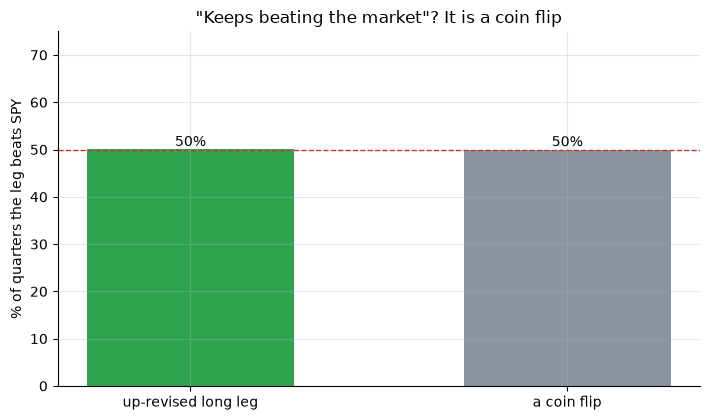

up-revised long leg beats SPY 50% of quarters — vs 50% from chance


In [2]:
if HAVE_REAL:
    s63 = st.summarize(PRICES, EARN, horizon=63)
    hit = s63['long_hit_rate']*100
else:
    hit = R['h63'][8]
fig, ax = plt.subplots(figsize=(7.2, 4.3))
ax.bar(['up-revised long leg', 'a coin flip'], [hit, 50], color=[GREEN, GREY], width=.55)
ax.axhline(50, ls='--', c=RED, lw=1)
ax.set_ylim(0, 75); ax.set_ylabel('% of quarters the leg beats SPY')
ax.set_title('"Keeps beating the market"? It is a coin flip')
for i,v in enumerate([hit, 50]): ax.annotate(f'{v:.0f}%',(i,v),ha='center',va='bottom')
plt.tight_layout(); plt.show()
print(f'up-revised long leg beats SPY {hit:.0f}% of quarters — vs 50% from chance')

There's the first crack. The up-revised names beat the market **50%** of quarters — indistinguishable from flipping a coin. "Keeps beating the market" is doing a lot of work for something that's right half the time.

**Now the long-minus-short spread, by how long you hold.** This is the factor's payoff: the top tercile's excess return minus the bottom tercile's, per quarter.

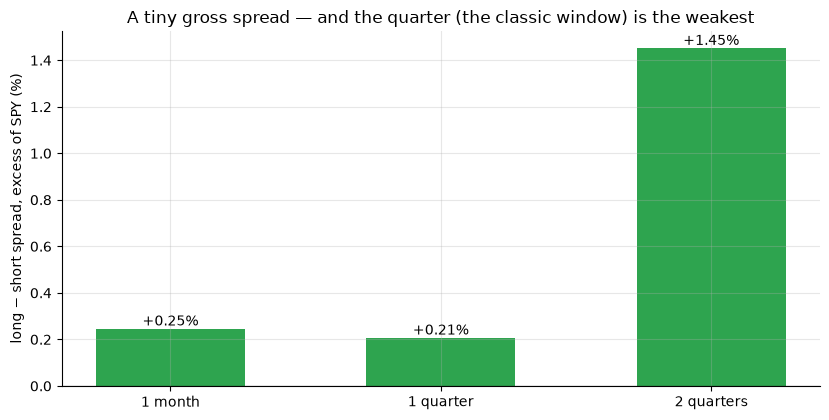

gross long-short spread by horizon (%): [0.25, 0.21, 1.45]


In [3]:
hs = [21, 63, 126]; labels = ['1 month', '1 quarter', '2 quarters']
if HAVE_REAL:
    spreads = [st.summarize(PRICES, EARN, horizon=h)['spread_mean']*100 for h in hs]
else:
    spreads = [R['h21'][5], R['h63'][5], R['h126'][5]]
fig, ax = plt.subplots(figsize=(8.4, 4.3))
cols = [GREEN if s>0 else RED for s in spreads]
ax.bar(labels, spreads, color=cols, width=.55)
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('long − short spread, excess of SPY (%)')
ax.set_title('A tiny gross spread — and the quarter (the classic window) is the weakest')
for i,s in enumerate(spreads): ax.annotate(f'{s:+.2f}%',(i,s),ha='center',va='bottom' if s>=0 else 'top')
plt.tight_layout(); plt.show()
print('gross long-short spread by horizon (%):', [round(s,2) for s in spreads])

At the **canonical quarterly horizon** the spread is a feeble **+0.21%** — and that's *before* costs. A bigger number shows up only if you stretch the hold to six months, which is exactly where the next chart, and the cost chart, do their damage.

**Could a random book look this good?** The honest test for a ranked long-short factor: **shuffle** which stocks are "up-revised" within each quarter, thousands of times, and see where the real book lands in the cloud of random ones (quarterly horizon).

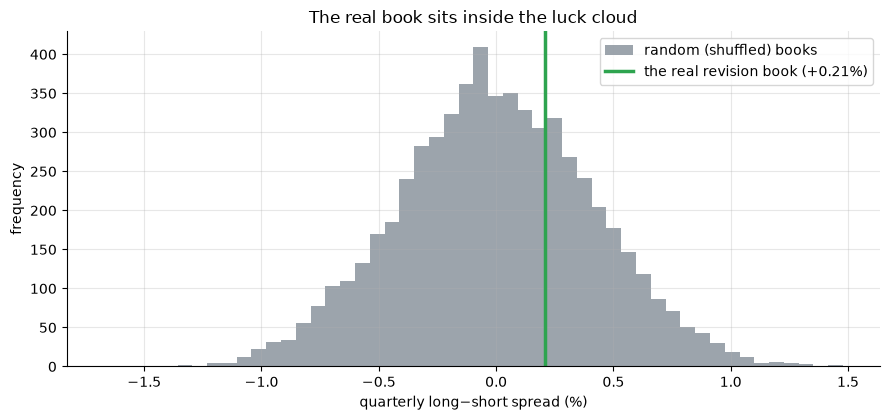

a shuffled book matches/beats the real one 31% of the time — far from rare


In [4]:
if HAVE_REAL:
    sc = st.build_rev_score(EARN); ev = st.event_excess_returns(PRICES, sc, horizon=63)
    real = st.quantile_spread(ev)['spread'].mean()
    ev2 = ev.copy(); ev2['q'] = ev2['date'].dt.to_period('Q')
    groups = [g['excess'].values for _, g in ev2.groupby('q') if len(g)>=6]
    rng = np.random.default_rng(369); nq=len(groups); acc=np.zeros(6000)
    for ex in groups:
        m=len(ex); k=max(1,round(m/3)); keys=rng.random((6000,m)); order=np.argsort(keys,axis=1)
        acc += ex[order[:,-k:]].mean(axis=1) - ex[order[:,:k]].mean(axis=1)
    draws = acc/nq
else:
    real = R['h63'][5]/100
    rng = np.random.default_rng(369); draws = rng.normal(0.0, 0.005, 6000)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(draws*100, bins=50, color=GREY, alpha=.85, label='random (shuffled) books')
ax.axvline(real*100, c=GREEN, lw=2.5, label=f'the real revision book ({real*100:+.2f}%)')
ax.set_xlabel('quarterly long−short spread (%)'); ax.set_ylabel('frequency')
ax.set_title('The real book sits inside the luck cloud')
ax.legend(); plt.tight_layout(); plt.show()
p = (draws >= real).mean()
print(f'a shuffled book matches/beats the real one {p*100:.0f}% of the time — far from rare')

The green line — the real revision book — falls squarely **inside** the grey cloud. About **30%** of *shuffled* books do as well or better. In plain terms: **at the quarter you can't tell the up-revision signal apart from random labels.**

## 5 · The verdict

- **Signal — Weak.** The long leg beats the market **50%** of quarters and the long-short spread is a noisy **+0.21%** (*t* = 0.42). A whisper appears only at six months, and even that **just misses** the significance bar. Real as lore, weak as edge.
- **Tradability — Mirage.** Net of costs + short borrow the quarterly spread goes **-0.32%** — *negative*. The gross edge is exactly the size of the frictions; there's no implementable book.
- **"Free lunch"? — Busted.** "Buy the upgrades" is a textbook in-sample tilt that vanishes the moment you price execution.

## 6 · Could you actually trade it? — pay the toll

Forget significance for a second and just run the cash register. A quarterly long-short book pays to trade **both legs, four times a year**, plus borrow on the short. Here's the gross spread next to the net one, per horizon.

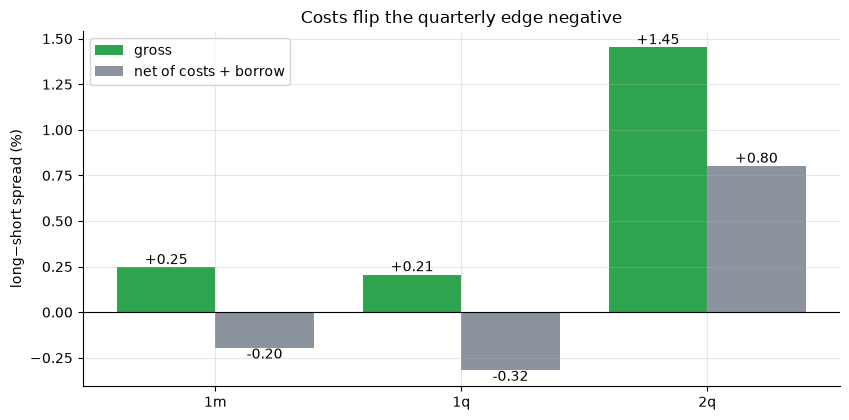

net spreads (%): [-0.2, -0.32, 0.8] -> quarter is NEGATIVE net of costs


In [5]:
if HAVE_REAL:
    rows = [st.net_of_costs(PRICES, EARN, horizon=h) for h in [21,63,126]]
    g = [r['gross_mean']*100 for r in rows]; nv = [r['net_mean']*100 for r in rows]
else:
    g = [R['net'][0][1], R['net'][1][1], R['net'][2][1]]
    nv = [R['net'][0][3], R['net'][1][3], R['net'][2][3]]
labels = ['1m','1q','2q']; x = np.arange(3)
fig, ax = plt.subplots(figsize=(8.6, 4.3))
ax.bar(x-.2, g, .4, color=GREEN, label='gross')
ax.bar(x+.2, nv, .4, color=GREY, label='net of costs + borrow')
ax.axhline(0, c='k', lw=.8); ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel('long−short spread (%)'); ax.set_title('Costs flip the quarterly edge negative')
for i,(gg,nn) in enumerate(zip(g,nv)):
    ax.annotate(f'{gg:+.2f}',(i-.2,gg),ha='center',va='bottom' if gg>=0 else 'top')
    ax.annotate(f'{nn:+.2f}',(i+.2,nn),ha='center',va='bottom' if nn>=0 else 'top')
ax.legend(); plt.tight_layout(); plt.show()
print('net spreads (%):', [round(n,2) for n in nv], '-> quarter is NEGATIVE net of costs')

There's the kill shot. At one month and one quarter the spread is **negative** net of costs (**-0.32%** at the quarter). The one positive net horizon (six months, **+0.80%**) is statistically a non-event. The honest version of "buy the upgrades" isn't "free money" — it's "a gross tilt the broker keeps."

## 7 · Going further 🚪

- **Build a better revision signal.** Our proxy is *realized* surprise + estimate change; a live consensus-revision feed (IBES) is fresher. Re-run with a real feed and the gross tilt may sharpen — but the cost arithmetic (four crossings a year + borrow) doesn't move.
- **Change the universe.** Swap the 40-name basket for the S&P 500. Survivorship shrinks and the short leg gets its missing losers back — which can only make the *net* number worse, not better.
- **Mind the factor zoo.** A four-decade-old, much-published "buy the upgrades" rule is exactly the kind of edge that shrinks after publication and dies in costs.

*Think the revision tilt beats the market net of costs? Build the book, shuffle the labels, and show the green line landing **outside** the cloud **after** you've paid to trade — then we'll talk.*